# Storm Track Map Description Generator

Generates storm track map descriptions for a fixed set of bulletin PDFs.
Each bulletin is processed independently — no shared state with other notebooks.

For each stem:
1. Runs Marker on the full PDF to extract bulletin text (all pages)
2. Converts page 1 to PNG and runs Marker again to extract the chart figure
3. Extracts Track and Intensity Forecast / Outlook sections from the text
4. Runs Gemma 4 vision on the chart, grounded by the official text
5. Writes `storm_track_map.md` and `chart.png` to `11-storm-track-map/output/{stem}/`

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
# Reload after prompt edits — re-run this cell to pick up any changes to ocr_marker.py
import importlib
import modal_etl.core.ocr_marker
importlib.reload(modal_etl.core.ocr_marker)
from modal_etl.core.ocr_marker import (
    _run_marker,
    _select_chart,
    _describe_chart,
    _extract_track_sections,
)
print("\u2713 Reloaded ocr_marker")

✓ Reloaded ocr_marker


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
OLLAMA_URL = "http://localhost:11434"
MODEL      = "gemma4:e4b"
FORCE_RUN  = True   # always regenerate — this notebook is for prompt iteration

ARCHIVE    = Path("../data/bulletin-archive/archive")
OUTPUT_DIR = Path("11-storm-track-map/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# (storm_folder, stem)
STEMS = [
    ("pagasa-20-19W",  "PAGASA_20-19W_Pepito_SWB#01"),
    ("pagasa-22-TC02", "PAGASA_22-TC02_Basyang_TCA#01"),
    ("pagasa-25-TC22", "PAGASA_25-TC22_Verbena_TCB#24"),
    ("pagasa-26-TC02", "PAGASA_26-TC02_Basyang_TCB#23"),
]

print(f"Output: {OUTPUT_DIR.resolve()}")
print(f"FORCE_RUN: {FORCE_RUN}")

Output: /Users/josereyes/Dev/gemma4-hackathon/notebooks/11-storm-track-map/output
FORCE_RUN: True


In [4]:
from pdf2image import convert_from_path

for storm_folder, stem in STEMS:
    pdf_path  = ARCHIVE / storm_folder / f"{stem}.pdf"
    out_dir   = OUTPUT_DIR / stem
    out_dir.mkdir(parents=True, exist_ok=True)
    map_path  = out_dir / "storm_track_map.md"
    chart_path = out_dir / "chart.png"

    if map_path.exists() and not FORCE_RUN:
        print(f"[{stem}] already exists, skipping")
        continue

    if not pdf_path.exists():
        print(f"[{stem}] PDF not found: {pdf_path}")
        continue

    # Step 1 — extract full text + chart figure
    print(f"[{stem}] running Marker...")
    markdown, figures = _run_marker(pdf_path)
    print(f"[{stem}] Marker: {len(markdown)} chars, {len(figures)} figures")

    # Step 2 — save chart.png
    chart_img = _select_chart(figures)
    if chart_img is None:
        print(f"[{stem}] no figure extracted, falling back to page 1")
        pages = convert_from_path(str(pdf_path), dpi=200, first_page=1, last_page=1)
        chart_img = pages[0] if pages else None

    if chart_img is None:
        print(f"[{stem}] could not obtain chart image — skipping")
        continue

    chart_img.save(str(chart_path), format="PNG")
    print(f"[{stem}] chart.png saved ({chart_img.size[0]}x{chart_img.size[1]})")

    # Step 3 — extract track sections and describe the chart
    track_text = _extract_track_sections(markdown)
    print(f"[{stem}] track text: {len(track_text)} chars")
    print(f"[{stem}] running chart description...")

    description = _describe_chart(chart_path, OLLAMA_URL, MODEL, track_text=track_text)

    map_path.write_text(description, encoding="utf-8")
    print(f"[{stem}] wrote storm_track_map.md ({len(description)} chars)\n")

print("Done.")

[PAGASA_20-19W_Pepito_SWB#01] running Marker...


/Users/josereyes/Dev/gemma4-hackathon/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded layout model s3://layout/2025_02_18 on device mps with dtype torch.float16
Loaded texify model s3://texify/2025_02_18 on device mps with dtype torch.float16
Loaded recognition model s3://text_recognition/2025_02_18 on device mps with dtype torch.float16
Loaded table recognition model s3://table_recognition/2025_02_18 on device mps with dtype torch.float16
Loaded detection model s3://text_detection/2025_02_28 on device mps with dtype torch.float16
Loaded detection model s3://inline_math_detection/2025_02_24 on device mps with dtype torch.float16


Running OCR Error Detection: 100%|██████████| 1/1 [00:00<00:00, 15.99it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Recognizing tables: 100%|██████████| 1/1 [00:01<00:00,  1.33s/it]


[PAGASA_20-19W_Pepito_SWB#01] Marker: 3080 chars, 6 figures
[PAGASA_20-19W_Pepito_SWB#01] no figure extracted, falling back to page 1
[PAGASA_20-19W_Pepito_SWB#01] chart.png saved (1700x2600)
[PAGASA_20-19W_Pepito_SWB#01] track text: 818 chars
[PAGASA_20-19W_Pepito_SWB#01] running chart description...
[PAGASA_20-19W_Pepito_SWB#01] wrote storm_track_map.md (1979 chars)

[PAGASA_22-TC02_Basyang_TCA#01] running Marker...


...

[PAGASA_22-TC02_Basyang_TCA#01] Marker: 5076 chars, 3 figures
[PAGASA_22-TC02_Basyang_TCA#01] chart.png saved (1365x685)
[PAGASA_22-TC02_Basyang_TCA#01] track text: 2556 chars
[PAGASA_22-TC02_Basyang_TCA#01] running chart description...
[PAGASA_22-TC02_Basyang_TCA#01] wrote storm_track_map.md (2319 chars)

[PAGASA_25-TC22_Verbena_TCB#24] running Marker...


Running OCR Error Detection: 100%|██████████| 1/1 [00:00<00:00,  4.15it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Recognizing tables: 100%|██████████| 1/1 [00:01<00:00,  1.70s/it]


[PAGASA_25-TC22_Verbena_TCB#24] Marker: 14880 chars, 5 figures
[PAGASA_25-TC22_Verbena_TCB#24] chart.png saved (688x520)
[PAGASA_25-TC22_Verbena_TCB#24] track text: 2072 chars
[PAGASA_25-TC22_Verbena_TCB#24] running chart description...
[PAGASA_25-TC22_Verbena_TCB#24] wrote storm_track_map.md (2067 chars)

[PAGASA_26-TC02_Basyang_TCB#23] running Marker...


Running OCR Error Detection: 100%|██████████| 1/1 [00:00<00:00,  1.53it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Recognizing Text: 100%|██████████| 3/3 [00:28<00:00,  9.43s/it]
Detecting bboxes: 0it [00:00, ?it/s]


[PAGASA_26-TC02_Basyang_TCB#23] Marker: 5024 chars, 3 figures
[PAGASA_26-TC02_Basyang_TCB#23] chart.png saved (1439x582)
[PAGASA_26-TC02_Basyang_TCB#23] track text: 1394 chars
[PAGASA_26-TC02_Basyang_TCB#23] running chart description...
[PAGASA_26-TC02_Basyang_TCB#23] wrote storm_track_map.md (2163 chars)

Done.


---
## PAGASA_20-19W_Pepito_SWB#01

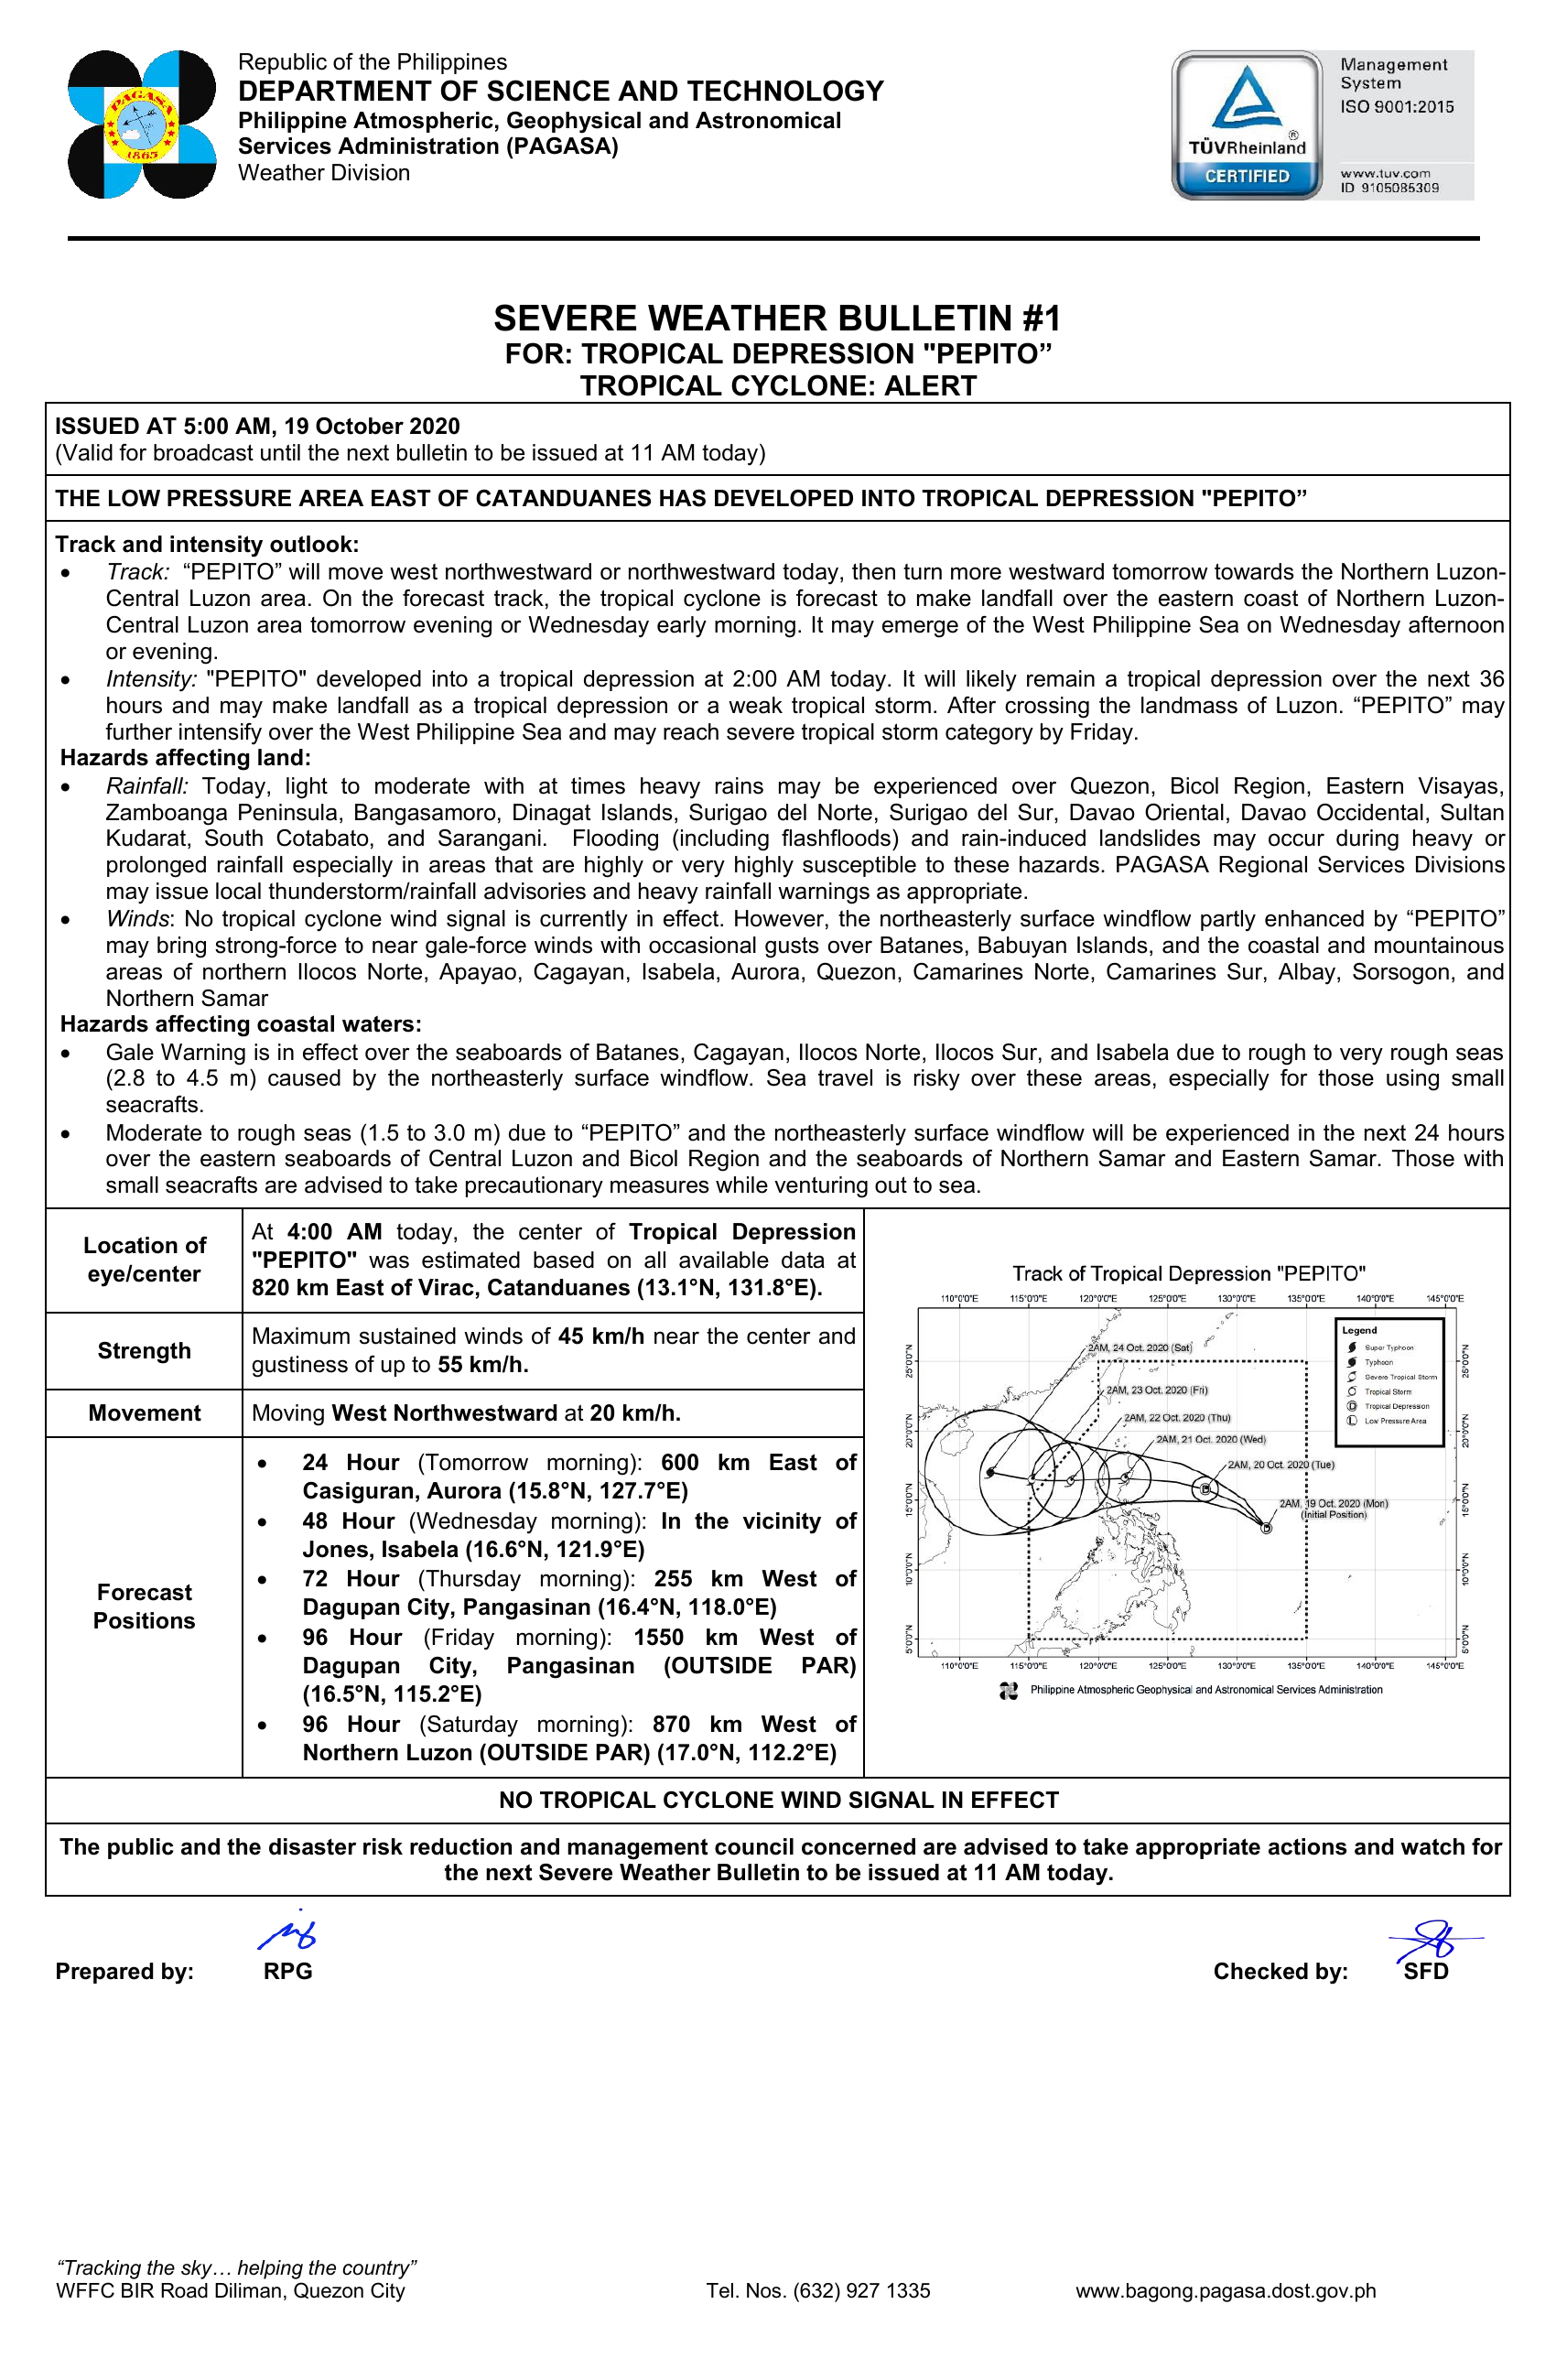

### Storm Track Map Analysis
The analysis begins by establishing the current position using the bulletin's issuance time of 5:00 AM on 19 October 2020, which serves as the Reference Timestamp. The current position is the latest plotted point before the forecast period begins. Sequencing the track involves reviewing all plotted timestamps chronologically; for instance, the path started several days prior (Past), confirming the cyclone's approach trajectory leading up to 19 October morning. The future forecast path shows a sustained movement from 19 October afternoon, through 20 October, and eventually reaching landmasses around 21 October and the open sea by 23 October. Comparing the Current Position to the LATEST future dot (approximately 23 October), the track shows a clear shift to the West and North. This defines a combined compass bearing of Northwest. Regarding proximity, the storm is initially heading directly toward the Philippine landmass, therefore the verdict is Moving Towards the Philippines.

### Storm Track Map Outlook
The cyclone, named "Pepito," was reported as a tropical depression at the time of the bulletin. Its immediate forecast trajectory indicates a shift to the west-northwest, tracking generally toward the Northern Luzon and Central Luzon regions. The storm is set to make landfall over the eastern coast of these islands by late tomorrow evening, or early Wednesday morning. This initial landfall marks a change in movement from its previous offshore path. After crossing the mainland, "Pepito" is forecast to continue moving westward, heading out into the West Philippine Sea. Over the course of the next two days, the storm is expected to maintain tropical depression status but could potentially intensify significantly, possibly reaching severe tropical storm strength by Friday. Mariners should prepare for increasing hazards as the system moves through the open sea and potentially brings strong winds and rough seas to the area.

---
## PAGASA_22-TC02_Basyang_TCA#01

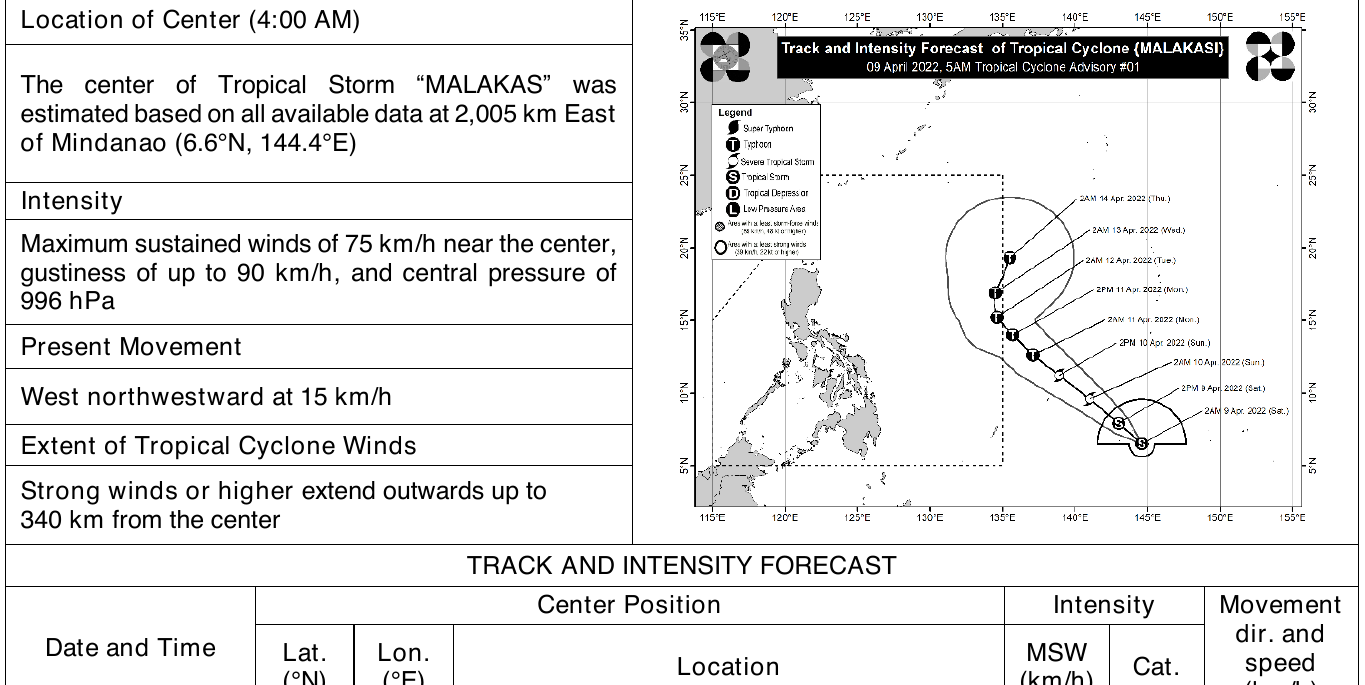

### Storm Track Map Analysis
The analysis begins by anchoring the timeline to the initial forecast point: 12-Hour Forecast at 2:00 PM on 09 April 2022, establishing the initial position at 7.9°N, 143.0°E. The forecast sequence records a total of eight data points. Chronologically, the path begins with this initial point (Past/Reference Start). The trajectory then progresses through a series of future points: 10 April (9.6°N, 141.0°E); 10 April (11.2°N, 138.9°E); 11 April (12.6°N, 137.1°E); 11 April (14.0°N, 135.7°E); 12 April (15.2°N, 134.6°E); 13 April (16.9°N, 134.5°E); and culminating at the final point, 14 April (19.3°N, 135.5°E). Comparing the Current Position (7.9°N, 143.0°E) to the LATEST future position (19.3°N, 135.5°E) reveals a significant increase in latitude (North) and a decrease in longitude (West). The combined spatial vector is therefore Northwest (NW). Regarding the Philippines, whose landmass spans 116°E–127°E, the storm’s longitude decreases from 143.0°E to 135.5°E. Since the longitude is continuously decreasing and remaining significantly east of the Philippine Area of Responsibility (PAR), the storm is unequivocally determined to be Moving Away from the Philippines.

### Storm Track Map Outlook
Tropical Cyclone MALAKASI is currently situated far to the east, approximately 1,835 km East of Mindanao, placing it outside the Philippine Area of Responsibility. The storm's projected path is a steady track heading Northwest. Over the next 72 hours, it is forecast to undergo significant strengthening, starting as a Tropical Storm, rapidly intensifying to a Severe Tropical Storm, and achieving its peak strength as a Typhoon. The movement is consistently projected to carry MALAKASI steadily West-Northwest, remaining entirely over the open ocean. The forecast path takes it successively past the general areas east of Mindanao, then east of the Visayas, and subsequently towards the vicinity of Southern and Central Luzon. While the storm's intensity remains potent—projecting to maintain typhoon-force winds—its trajectory steadily moves further away from the main Philippine landmass. By April 14, the storm is expected to be located roughly 1,475 km East of Extreme Northern Luzon, confirming a persistent path moving away from any immediate threat to the Philippine islands.

---
## PAGASA_25-TC22_Verbena_TCB#24

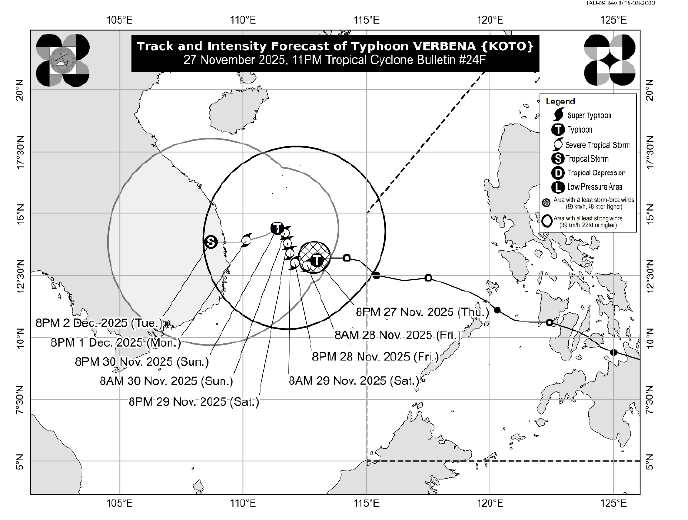

### Storm Track Map Analysis
The Reference Timestamp for this forecast analysis is centered around 27 November 2025, marking the beginning of the projected track. The current position dot, indicating the storm's established location, is analyzed by sequencing all subsequent timestamps. Chronologically, the sequence is: 8 AM 27 Nov (Past), 8 PM 27 Nov (Past), 8 AM 28 Nov (Future), 8 PM 28 Nov (Future), 8 AM 29 Nov (Future), 8 PM 29 Nov (Future), 8 AM 30 Nov (Future), and concluding at 8 PM 30 Nov (Future). The path confirms a general movement eastward and northward over time. Comparing the most recent position (8 PM 29 Nov) to the latest forecast point (8 PM 30 Nov), the coordinates show an increase in longitude (indicating eastward movement) and an increase in latitude (indicating northward movement). This combination dictates a combined compass bearing of Northeast. Regarding proximity, as the storm track begins west of the primary Philippine landmass but progresses steadily toward the 116°E–127°E range, the overall vector places the storm on a trajectory Moving Towards the Philippines.

### Storm Track Map Outlook
VERBENA is expected to follow a generally west-southwesterly track initially, then gradually shift to a west-northwesterly path through 28 November. During the weekend, the movement is forecast to trend north-northwestward, shifting the storm’s location into more open, deeper waters. For the remainder of the forecast period, the tropical cyclone is projected to take a gradual west-southwesterly or purely westward turn, steering toward the coast of Vietnam. Intensity is expected to undergo a slight weakening phase over the next two days, possibly being downgraded to a severe tropical storm. However, a period of re-intensification into a typhoon is possible over the weekend, following which the system is forecast to maintain a sustained weakening trend while maintaining its steady movement toward the Vietnamese landmass. Residents should be advised to monitor for shifts and extreme weather effects throughout this journey.

---
## PAGASA_26-TC02_Basyang_TCB#23

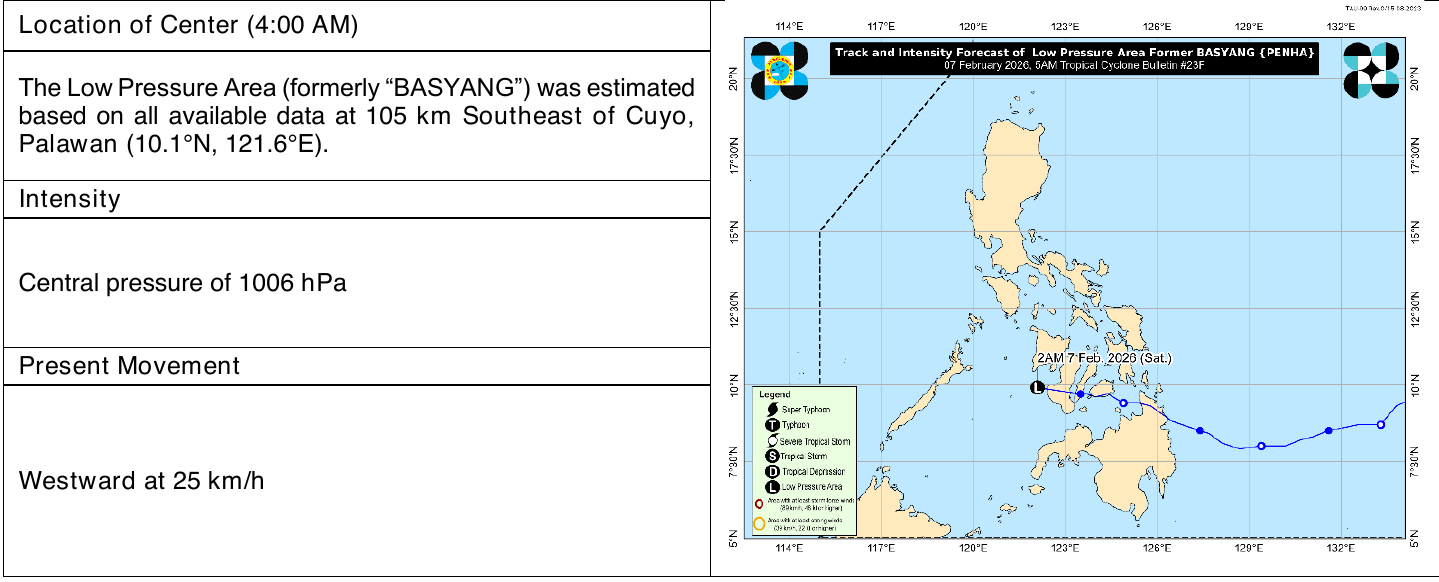

### Storm Track Map Analysis
The analysis begins by anchoring the timeline using the authoritative information provided in the PAGASA bulletin. The Reference Timestamp is 2:00 AM today, identifying the storm system as a low pressure area (LPA) that has weakened from BASYANG. The Current Position is situated at 105 km Southeast of Cuyo, Palawan. The forecast path, based on the narrative, shows a sustained movement over the Sulu Sea and subsequently crossing northern Palawan. Chronologically, the LPA established itself at 2:00 AM (Past), and the forecast path progresses West-Northwestward across the Sulu Sea and northern Palawan (Future). The predicted end point is potential dissipation within the Sulu Sea. Comparing the Current Position to the latest forecast dot, the system tracks generally West-Northwestward. This involves a continuous decrease in longitude (Westward movement) combined with a gradual movement across the Northern Philippines latitude, resulting in a West-Northwest bearing. Given that the system moves through the northern extent of the country's maritime domain and crosses Palawan, the verdict is that the system is moving directly across or over the northern Philippines.

### Storm Track Map Outlook
The weather disturbance, now classified as a low pressure area, has weakened considerably, reducing its strength as it moves over the Sulu Sea. Currently, the LPA is situated southeast of Cuyo, Palawan. Its anticipated track is generally West-Northwestward. Following this bearing, the system is forecast to continue its path over the vast Sulu Sea before moving into the northern stretch of Palawan. The forecast warns that as the system travels, it will encounter increasingly unfavorable environmental conditions. This transition suggests a high likelihood that the low pressure area may dissipate while it is located over the open waters of the Sulu Sea. While the system crosses the northern reaches of the Philippine landmass, its diminishing intensity means that the primary threat is associated with the heavy rainfall and associated weather warnings, requiring residents to remain vigilant and monitor local advisories.

In [5]:
# ── Display results ───────────────────────────────────────────────────────────
from IPython.display import display, Markdown, Image as IPImage

for storm_folder, stem in STEMS:
    map_path   = OUTPUT_DIR / stem / "storm_track_map.md"
    chart_path = OUTPUT_DIR / stem / "chart.png"

    display(Markdown(f"---\n## {stem}"))

    if chart_path.exists() and chart_path.stat().st_size > 0:
        display(IPImage(str(chart_path), width=600))

    if map_path.exists():
        display(Markdown(map_path.read_text(encoding="utf-8")))
    else:
        display(Markdown("_storm_track_map.md not generated — run the cell above_"))